In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df1=pd.read_csv("/content/Unemployment in India.csv")
df2=pd.read_csv("/content/Unemployment_Rate_upto_11_2020.csv")
urbanrural=df1.copy()
print(df1['Area'].value_counts())
df1.info()
df2.info()

Area
Urban    381
Rural    359
Name: count, dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 740 entries, 0 to 739
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    object 
 1    Date                                     740 non-null    object 
 2    Frequency                                740 non-null    object 
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    int64  
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    object 
dtypes: float64(2), int64(1), object(4)
memory usage: 40.6+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 267 entries, 0 to 266
Data columns (total 9 columns):
 #   Column                      

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1007 entries, 0 to 1006
Data columns (total 6 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    1007 non-null   object 
 1    Date                                     1007 non-null   object 
 2    Frequency                                1007 non-null   object 
 3    Estimated Unemployment Rate (%)          1007 non-null   float64
 4    Estimated Employed                       1007 non-null   int64  
 5    Estimated Labour Participation Rate (%)  1007 non-null   float64
dtypes: float64(2), int64(1), object(3)
memory usage: 47.3+ KB


/tmp/ipykernel_36509/1870586961.py:10: UserWarning: Parsing dates in  %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  combined_df['Date'] = pd.to_datetime(combined_df['Date'])


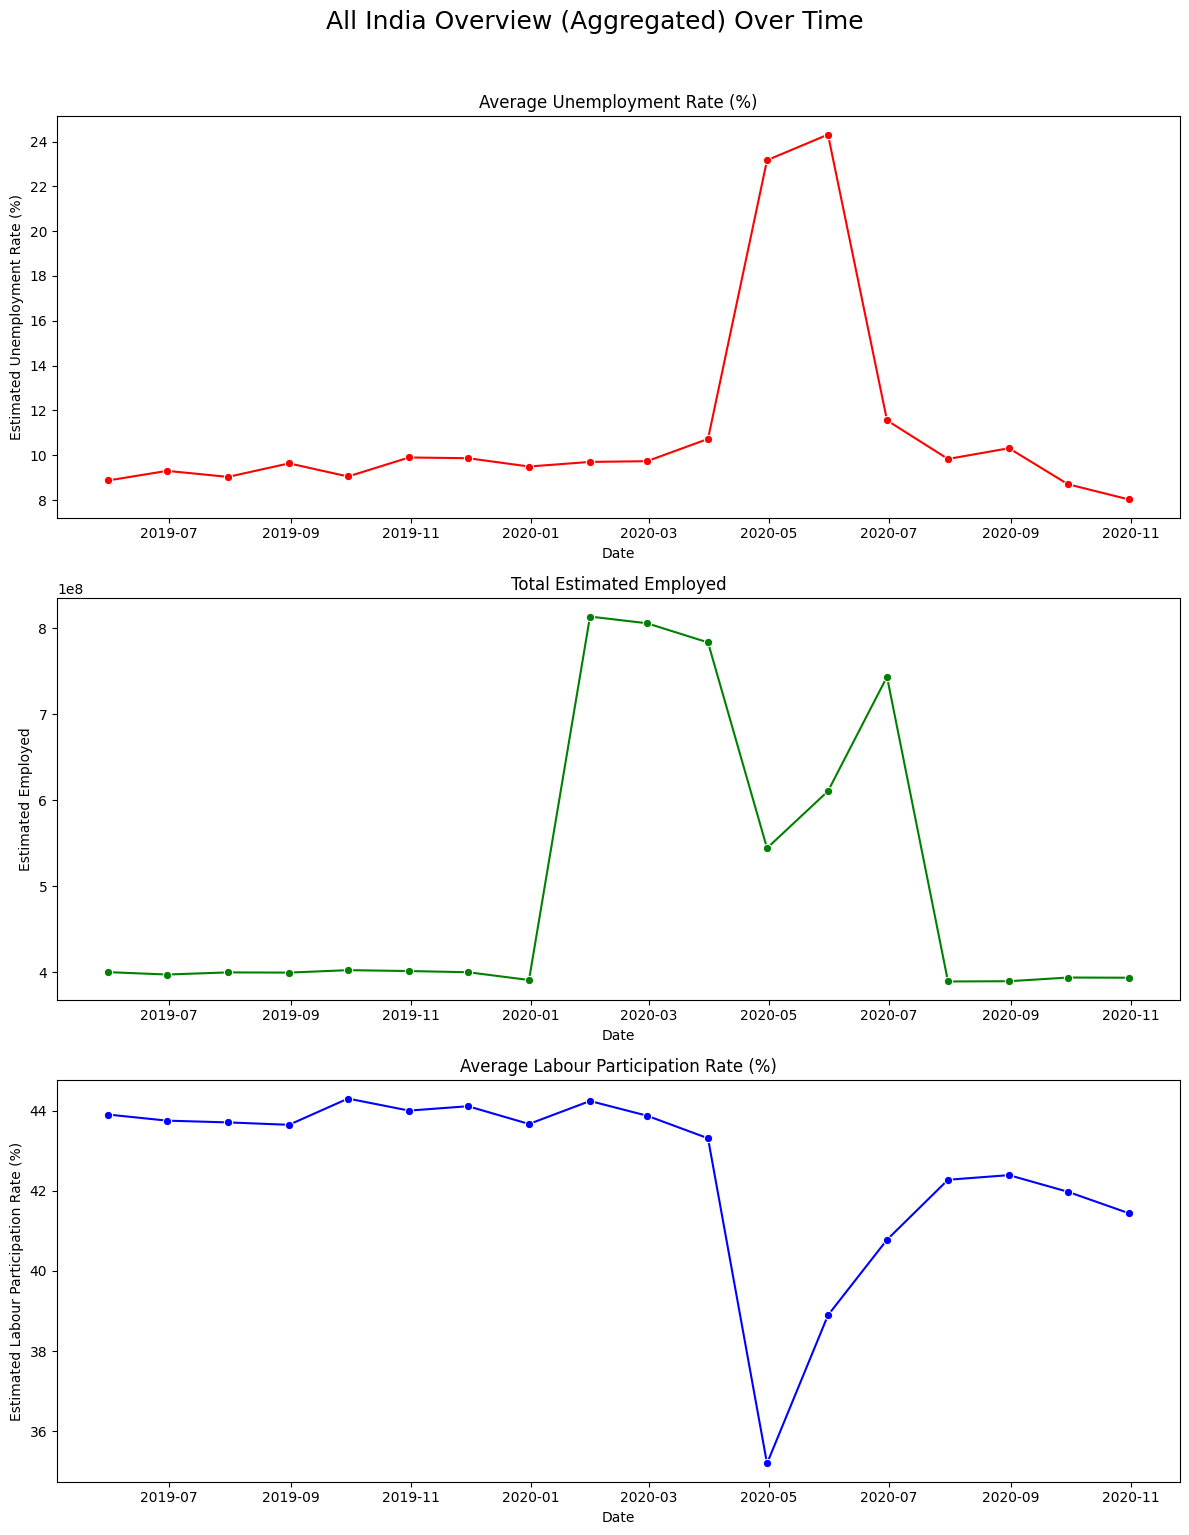

In [24]:
df1.drop('Area',axis=1,inplace=True)
df2.drop('longitude',axis=1,inplace=True)
df2.drop('latitude',axis=1,inplace=True)
df2.drop('Region.1',axis=1,inplace=True)
# Combine df1 and df2 vertically
combined_df = pd.concat([df1, df2], ignore_index=True)
combined_df.info()
combined_df.describe()
combined_df.columns = combined_df.columns.str.strip()
combined_df['Date'] = pd.to_datetime(combined_df['Date'])
combined_df = combined_df.sort_values(by='Date')

# Group by Date to get the national aggregate
# Sum for absolute numbers, Mean for rates
india_df = combined_df.groupby('Date').agg({
    'Estimated Unemployment Rate (%)': 'mean',
    'Estimated Employed': 'sum',
    'Estimated Labour Participation Rate (%)': 'mean'
}).reset_index()

# Create a figure with 3 subplots vertically
fig, axes = plt.subplots(3, 1, figsize=(12, 15))
fig.suptitle('All India Overview (Aggregated) Over Time', fontsize=18, y=1.02)

sns.lineplot(ax=axes[0], data=india_df, x='Date', y='Estimated Unemployment Rate (%)', marker='o', color='red')
axes[0].set_title('Average Unemployment Rate (%)')

sns.lineplot(ax=axes[1], data=india_df, x='Date', y='Estimated Employed', marker='o', color='green')
axes[1].set_title('Total Estimated Employed')

sns.lineplot(ax=axes[2], data=india_df, x='Date', y='Estimated Labour Participation Rate (%)', marker='o', color='blue')
axes[2].set_title('Average Labour Participation Rate (%)')

plt.tight_layout()
plt.show()

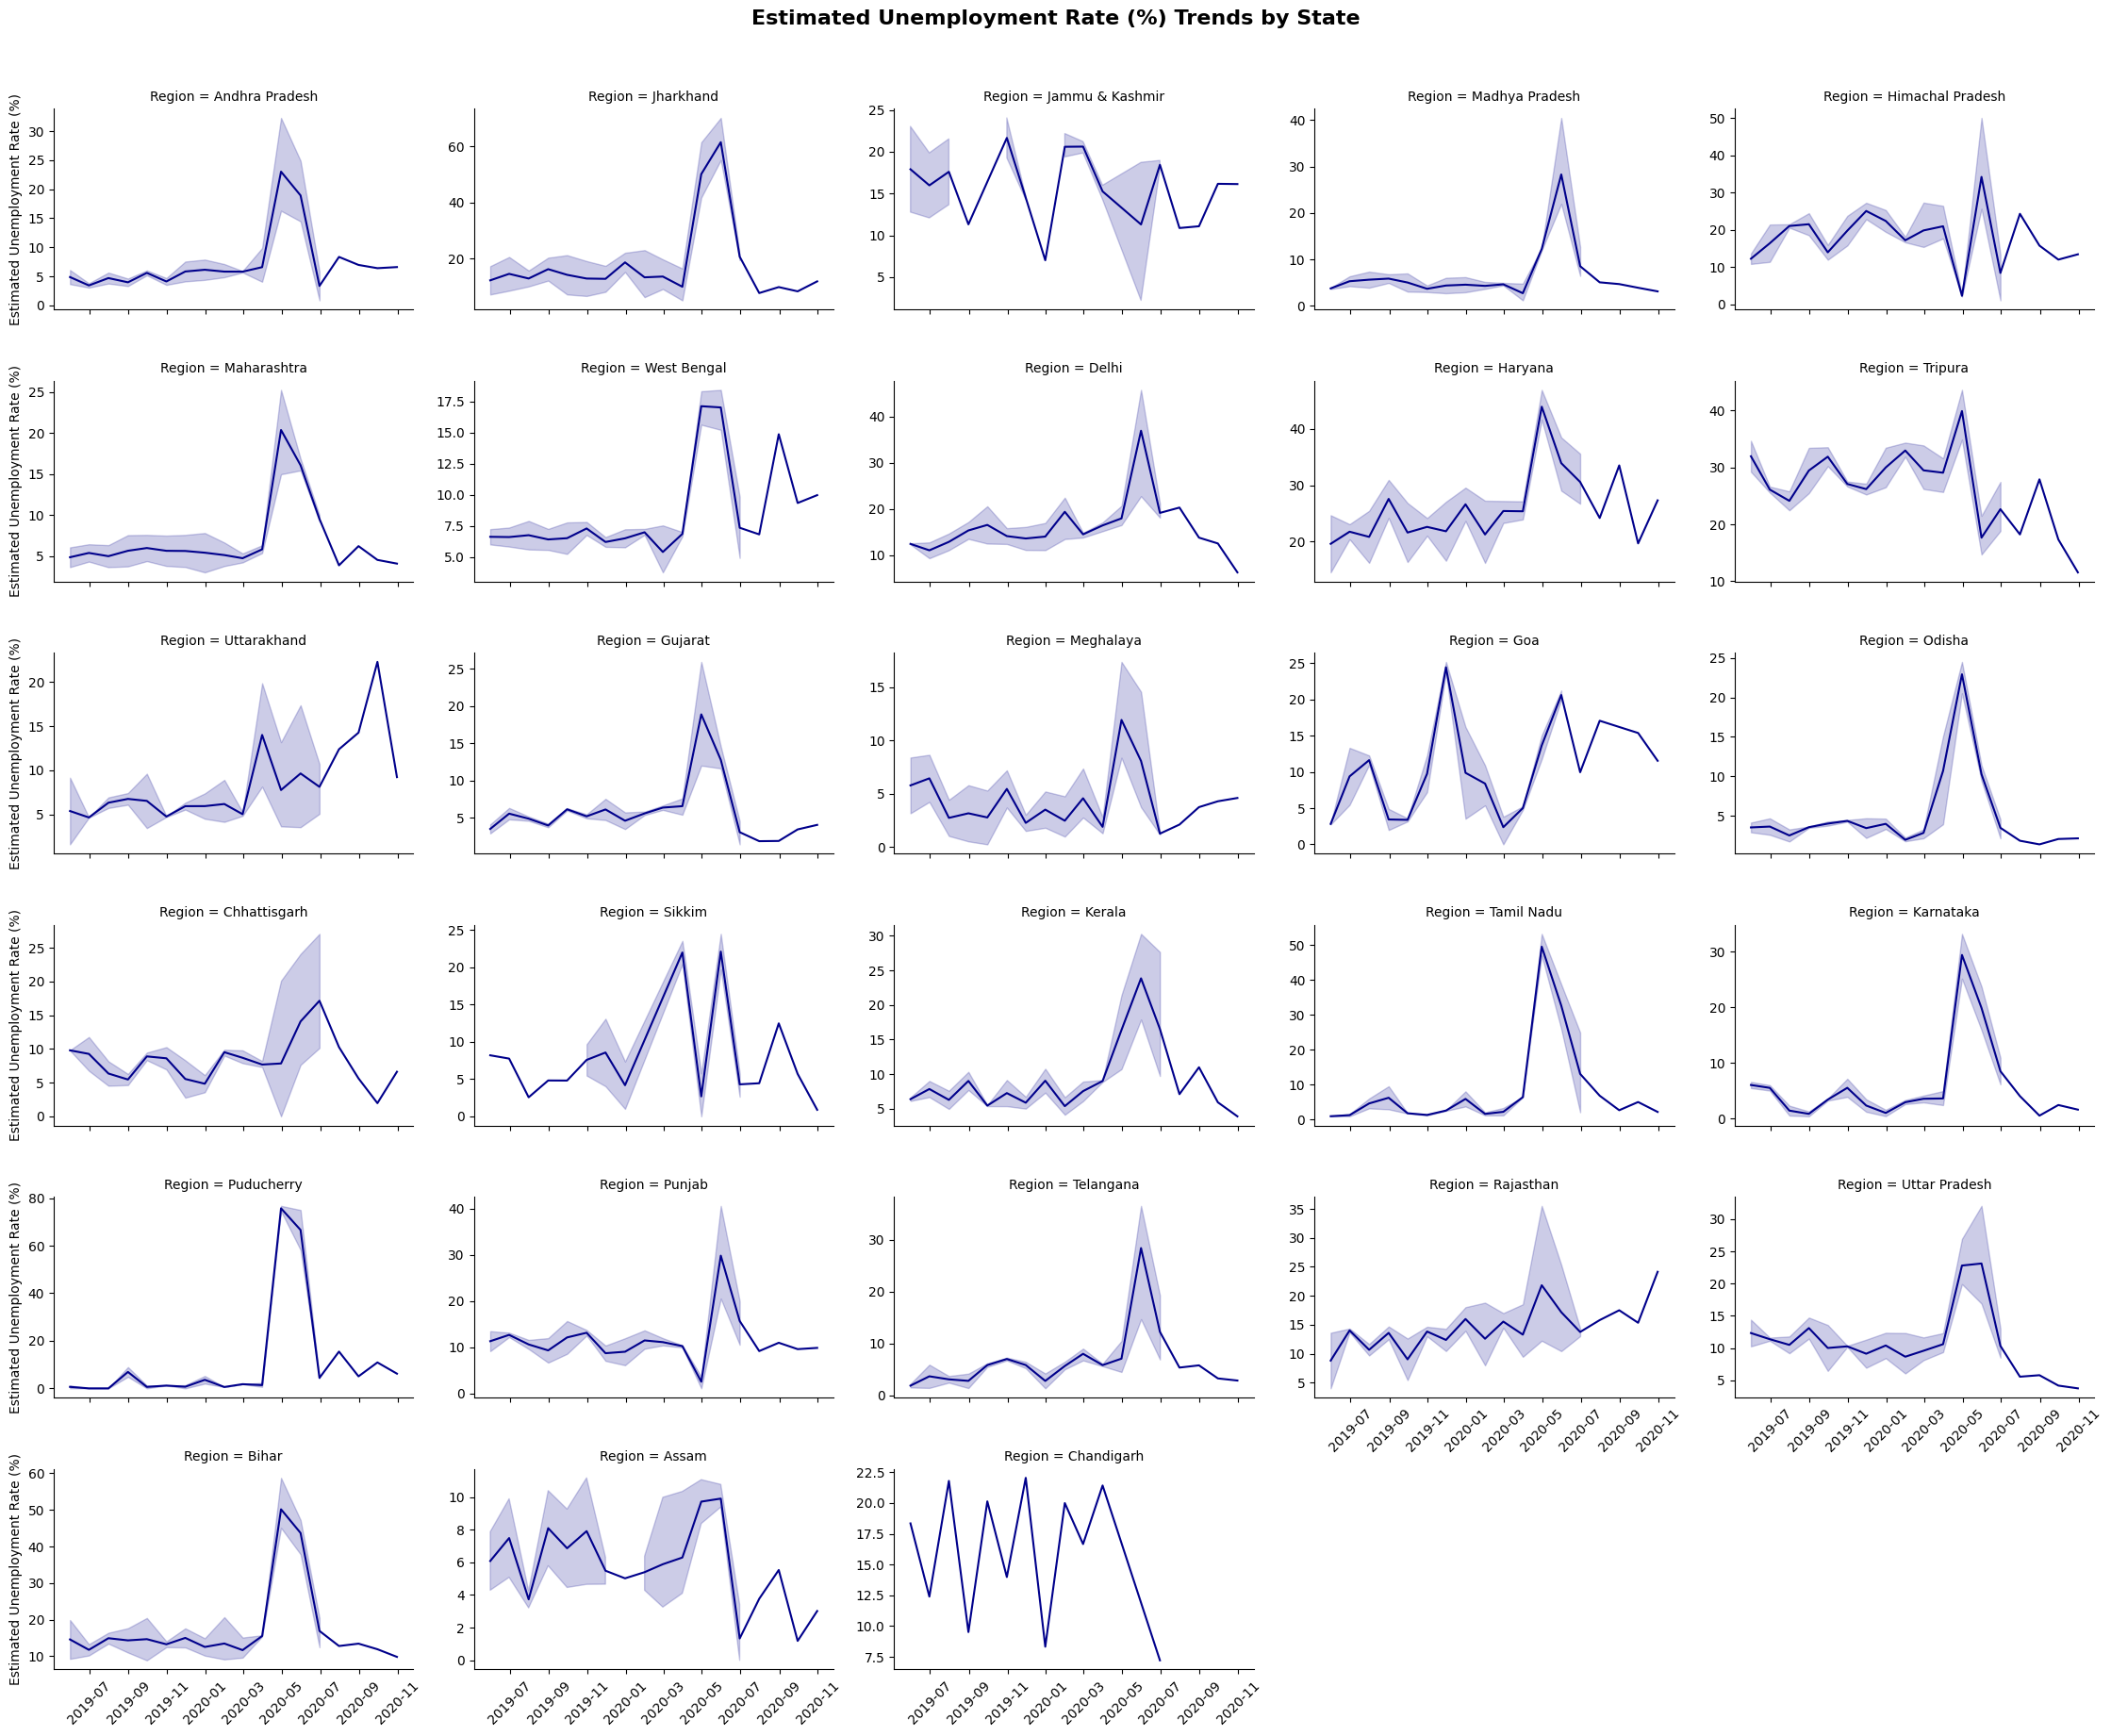

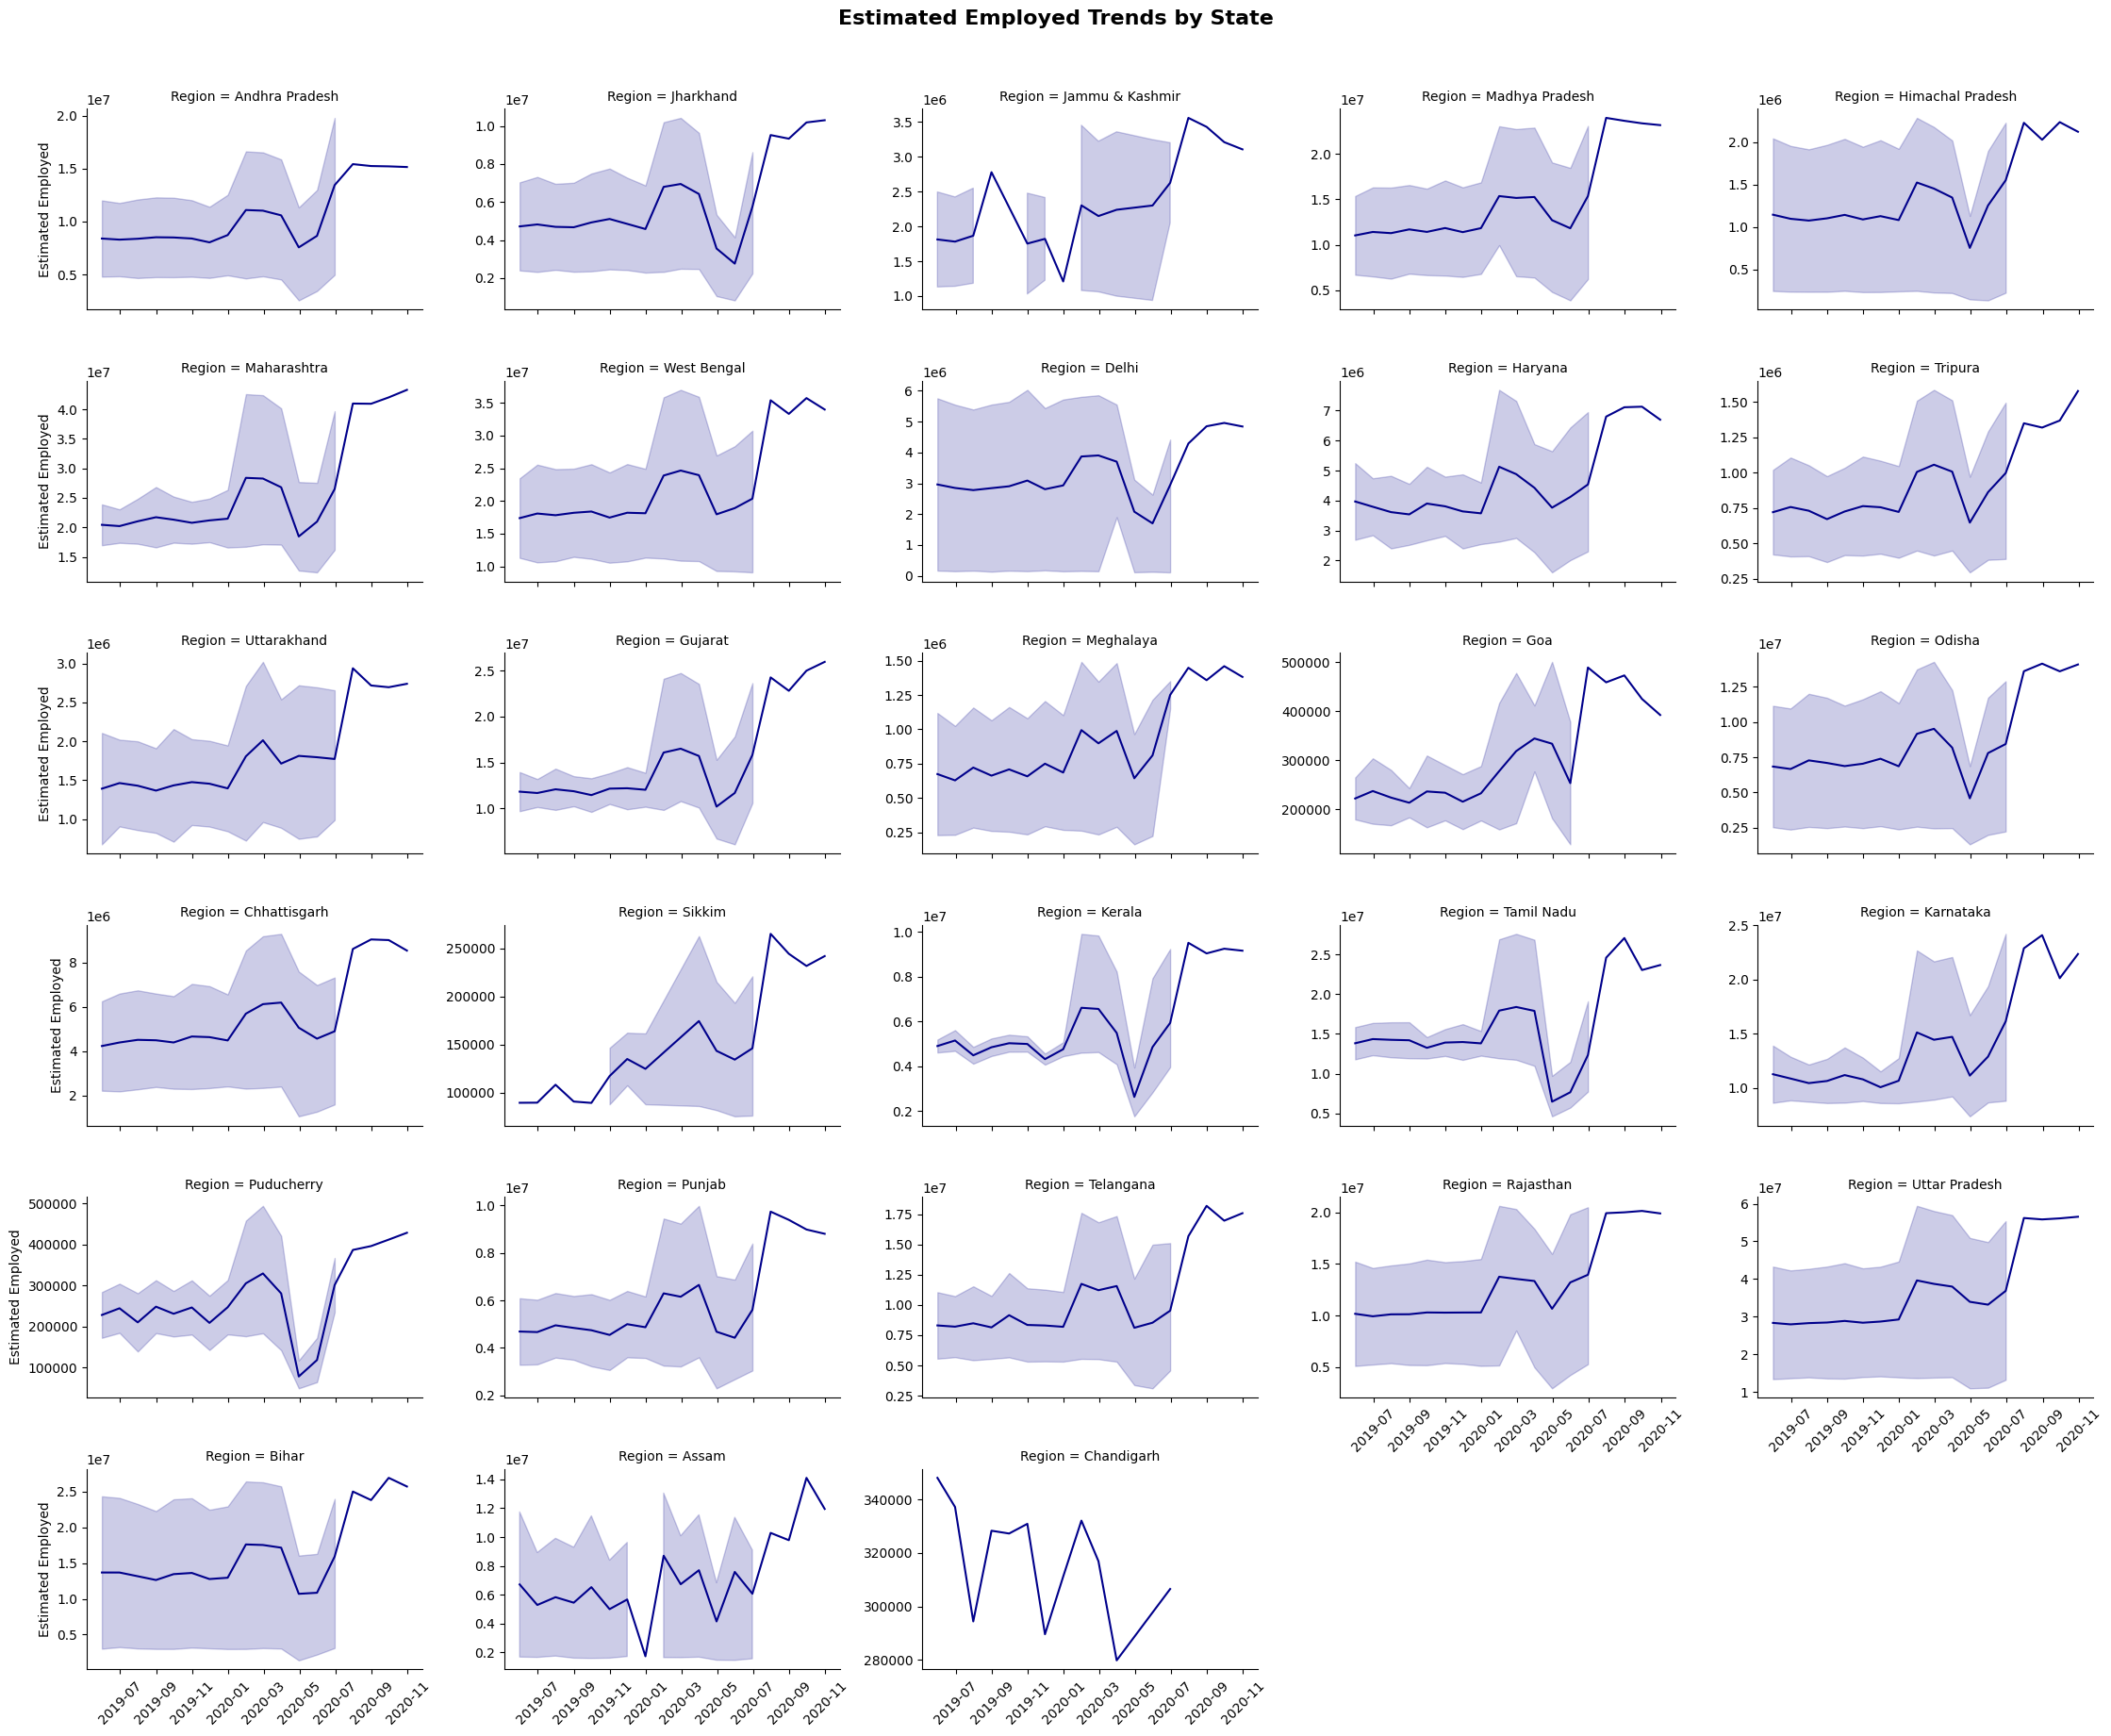

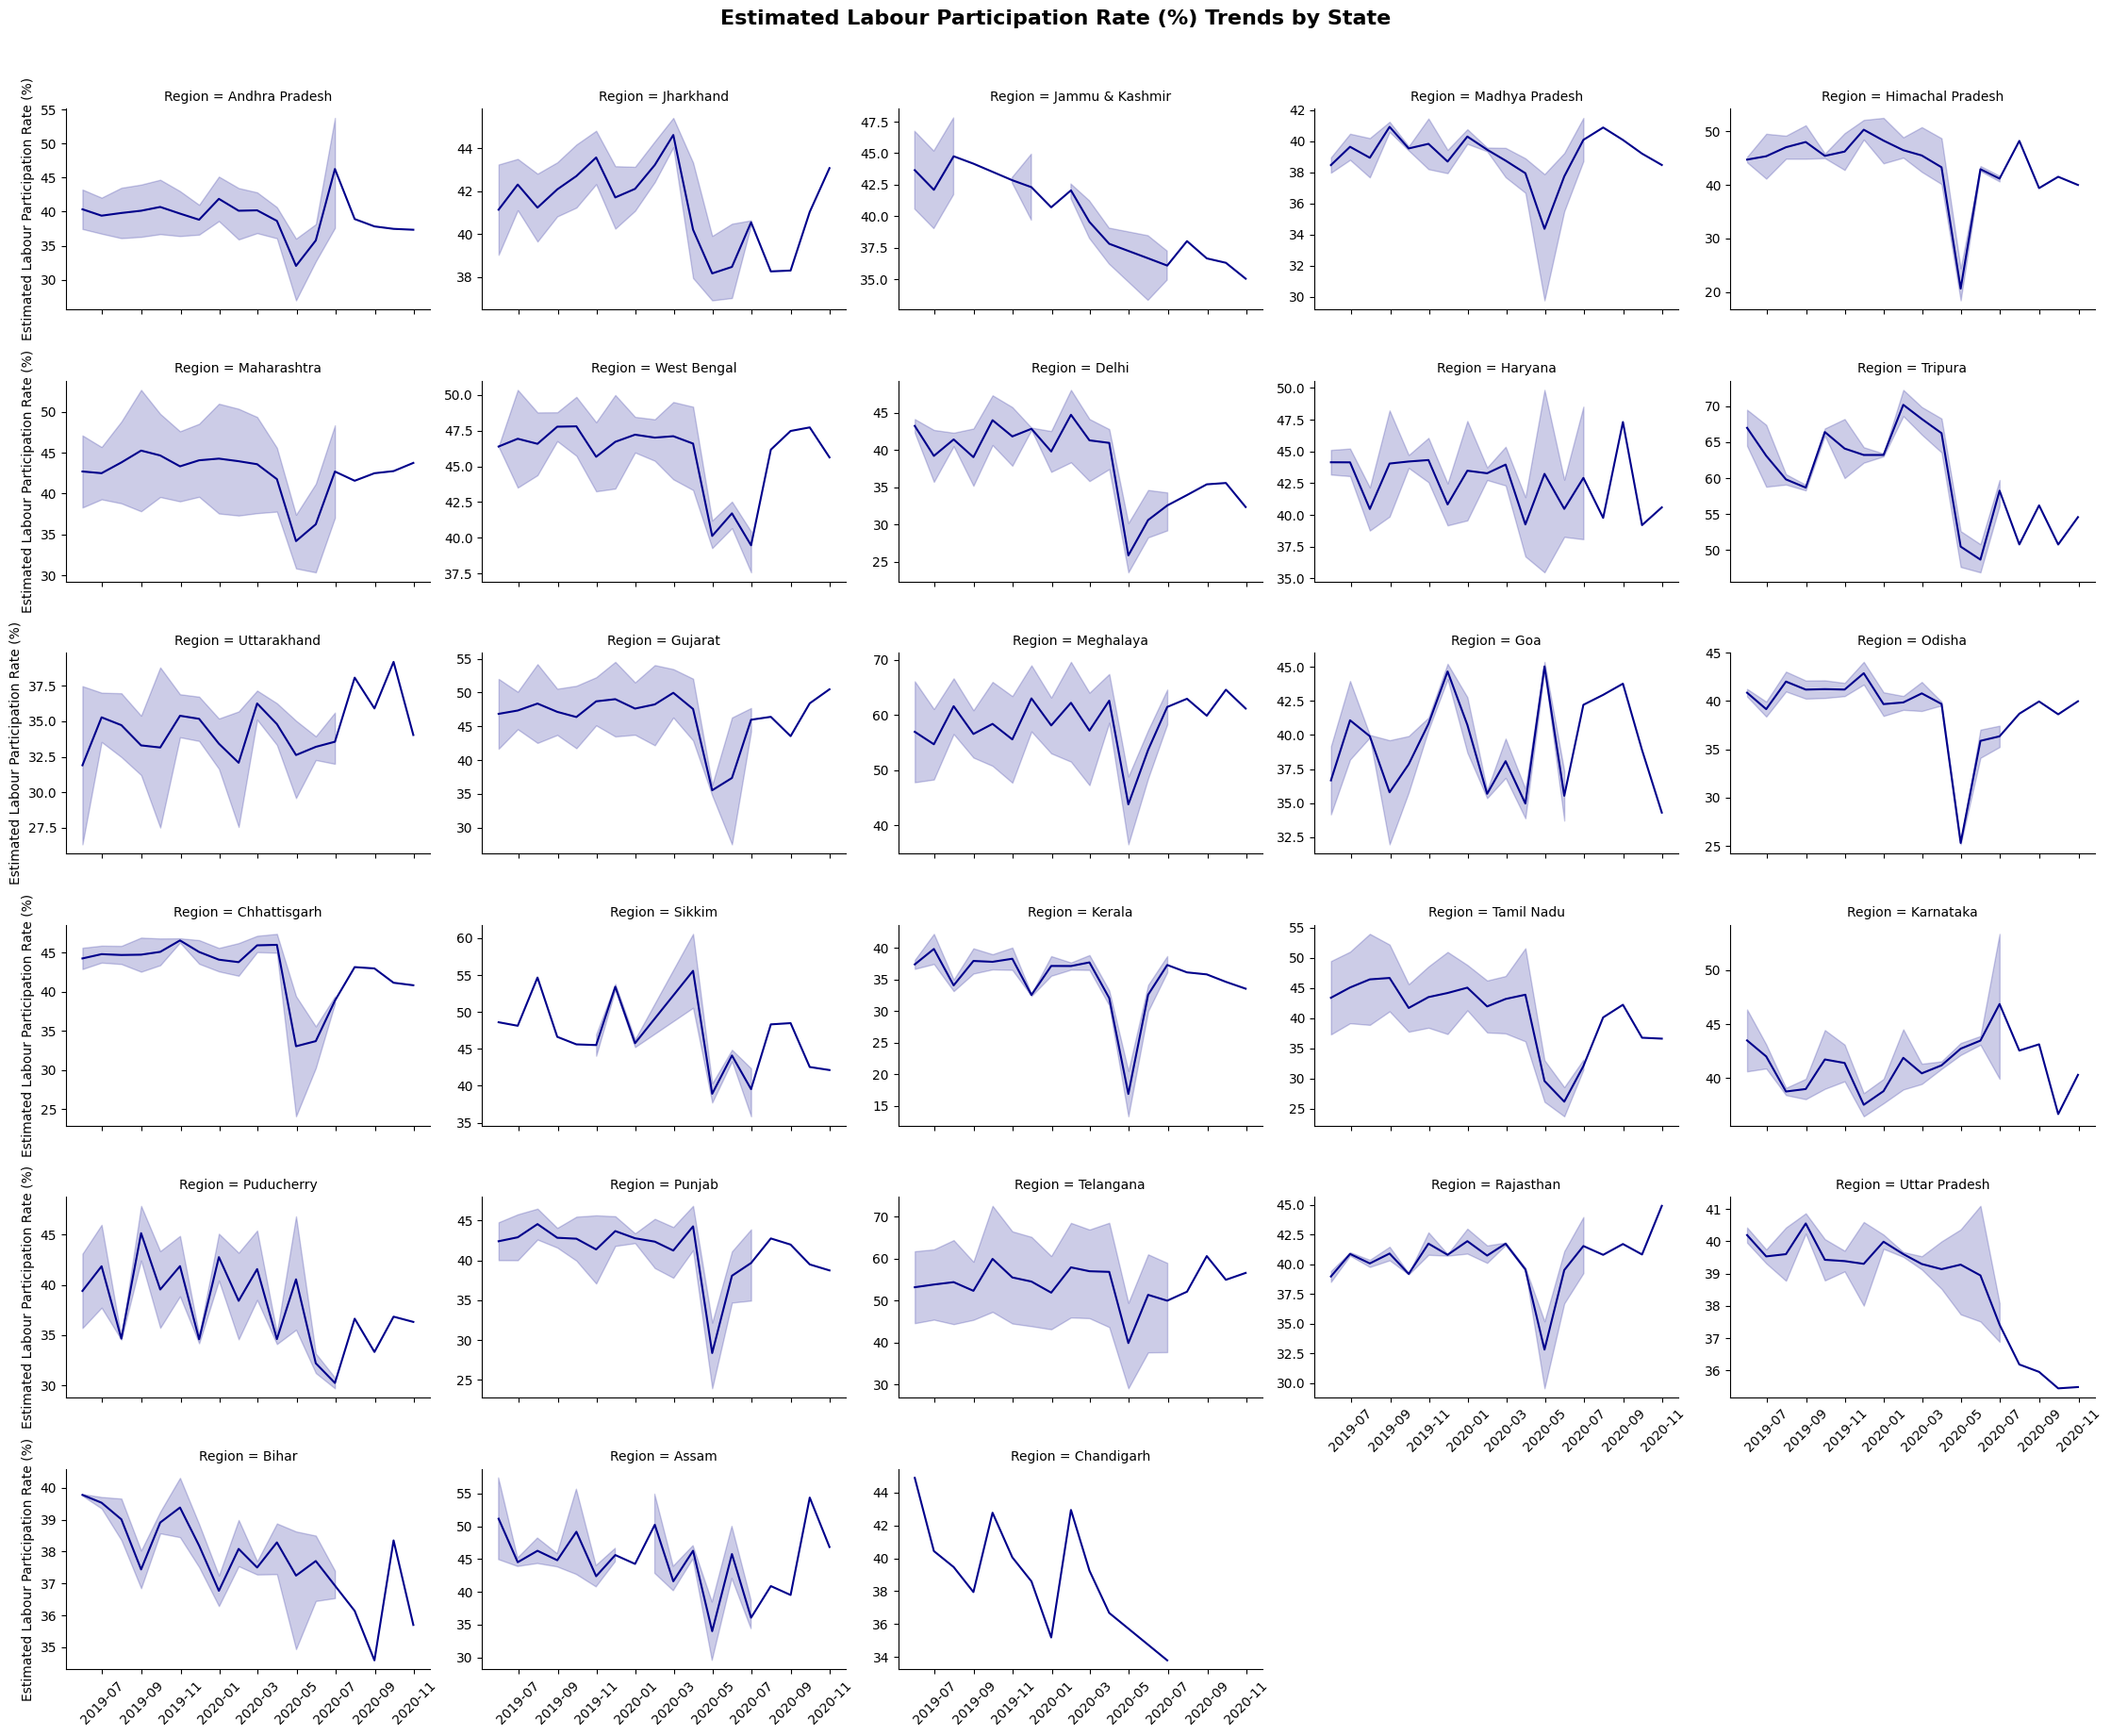

In [25]:
# List of the three metrics we want to plot
metrics = [
    'Estimated Unemployment Rate (%)',
    'Estimated Employed',
    'Estimated Labour Participation Rate (%)'
]

# Create a separate grid of plots for each metric
for metric in metrics:
    # relplot creates a grid of subplots based on the 'col' parameter
    g = sns.relplot(
        data=combined_df,
        x='Date',
        y=metric,
        col='Region',       # Create a new subplot for each Region
        col_wrap=5,         # Put 5 charts per row
        kind='line',
        height=3,           # Height of each individual subplot
        aspect=1.5,         # Width-to-height ratio of each subplot
        color='darkblue',   # Use a single clean color
        facet_kws={'sharey': False} # CRITICAL: Let each state scale its own Y-axis
    )

    # Add a main title to the entire grid
    g.fig.suptitle(f'{metric} Trends by State', y=1.02, fontsize=16, fontweight='bold')

    # Rotate the date labels on the X-axis so they don't overlap
    for ax in g.axes.flat:
        ax.tick_params(axis='x', labelrotation=45)
        ax.set_xlabel('') # Clean up redundant 'Date' labels

    plt.tight_layout()
    plt.show()

The Y-axes are not shared (each state scales to its own maximum to show the shape of the trend), a spike that visually looks massive in one state might actually be quite small mathematically compared to another.

By closely checking the numeric values on each individual Y-axis, here is the breakdown of the impact during that 2020 spike:

The Most Severely Affected (Peak Unemployment Rate):

Puducherry: The hardest hit by far. The Y-axis scales up to 80, and the peak nearly touches ~75%.

Jharkhand: Reached a devastating peak of roughly ~60%.

Bihar: Spiked to approximately ~50%.

Tamil Nadu & Haryana: Both saw massive surges pushing near or slightly above ~40-45%.

The Least Affected (Lowest Peak Unemployment Rate):

Assam: Despite the graph looking volatile, look at the Y-axis. The absolute maximum peak barely touches ~10%.

Meghalaya: The peak maxes out around ~12%.

Gujarat & Uttarakhand: Both managed to keep their peaks contained to roughly ~20%, which, while high, is significantly lower than the national extremes.

/tmp/ipykernel_36509/1167782773.py:2: UserWarning: Parsing dates in  %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  urbanrural['Date'] = pd.to_datetime(urbanrural['Date'])


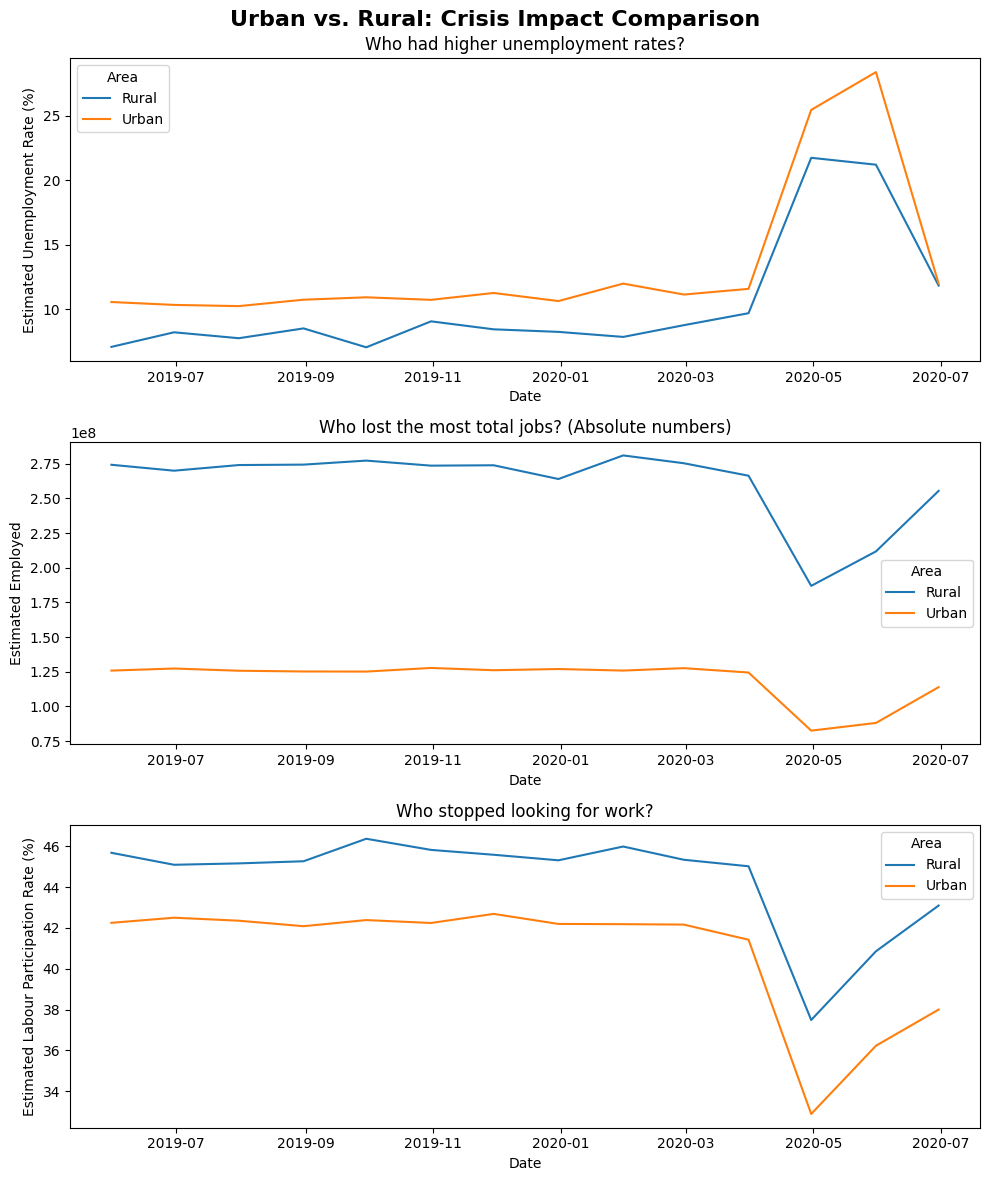

In [26]:
urbanrural.columns = urbanrural.columns.str.strip()
urbanrural['Date'] = pd.to_datetime(urbanrural['Date'])

# 3. Direct, no-nonsense plotting
fig, axes = plt.subplots(3, 1, figsize=(10, 12))
fig.suptitle('Urban vs. Rural: Crisis Impact Comparison', fontsize=16, fontweight='bold')

# Plot 1: Unemployment Rate
sns.lineplot(ax=axes[0], data=urbanrural, x='Date', y='Estimated Unemployment Rate (%)', hue='Area', errorbar=None)
axes[0].set_title('Who had higher unemployment rates?')

# Plot 2: Absolute Employment
sns.lineplot(ax=axes[1], data=urbanrural, x='Date', y='Estimated Employed', hue='Area', estimator='sum', errorbar=None)
axes[1].set_title('Who lost the most total jobs? (Absolute numbers)')

# Plot 3: Labour Participation
sns.lineplot(ax=axes[2], data=urbanrural, x='Date', y='Estimated Labour Participation Rate (%)', hue='Area', errorbar=None)
axes[2].set_title('Who stopped looking for work?')

plt.tight_layout()
plt.show()

The Rate: Urban unemployment always trended higher than Rural, but during the lockdown spike (April/May 2020), Urban rates skyrocketed to nearly 28-29%, while Rural rates peaked around 21-22%.

The Absolute Numbers: India's Rural workforce is massively larger than its Urban workforce. Before the crisis, roughly 275 million people were employed in Rural areas, compared to only 125 million in Urban areas.

The Drop: When the lockdown hit, the Rural employment line plummeted to roughly 185-190 million. That is an absolute loss of almost 85 to 90 million jobs. The Urban line dropped to roughly 80-85 million, representing a loss of roughly 40 to 45 million jobs.

The Baseline: Historically, Rural areas have higher participation (~45-46%) than Urban areas (~42%).

The Shock: During April and May 2020, both lines cratered. Urban participation dropped to roughly 33%, and Rural dropped to about 37%.

What this actually means: People did not just lose their jobs; millions completely exited the labor force. They stopped actively looking for work, likely due to severe movement restrictions and the realization that no businesses were hiring.

Unemployment rates quickly crashed back down toward their pre-crisis baselines of ~10%.

However, if you look closely at the tail ends of the "Employed" and "Participation" charts (July 2020), the lines have not fully recovered to their pre-March 2020 heights. This indicates that while the immediate shock ended rapidly, there was residual, lingering damage to the workforce size.